### Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Configurar semillas para reproducibilidad (Crucial para proyectos académicos)
np.random.seed(42)
tf.random.set_seed(42)

### 1. CARGA Y PREPROCESAMIENTO

In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

def preprocess_features(df):
    df = df.copy()
    # Ingeniería de variables con justificación física (CryoSleep vs Spends)
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[spend_cols] = df[spend_cols].fillna(0)
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['HasSpented'] = (df['TotalSpend'] > 0).astype(str) # Categórica para el pipeline
    
    # Datos de grupo
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0] if pd.notnull(x) else '0000')
    group_sizes = df['Group'].value_counts()
    df['GroupSize'] = df['Group'].map(group_sizes)
    df['IsAlone'] = (df['GroupSize'] == 1).astype(str)
    
    # Cabina
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['Cabin_Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['Cabin_Side'] = df['Cabin'].apply(lambda x: x.split('/')[-1])
    
    return df

train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)

num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize']
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'HasSpented', 'IsAlone']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

X = train_processed[num_features + cat_features]
y = train_processed['Transported'].astype(int).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)

### 2. EL BASELINE (Regresión Logística)

In [3]:
print("--- ENTRENANDO MODELO BASELINE ---")
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_trans, y_train)
baseline_preds = baseline_model.predict(X_val_trans)
baseline_acc = accuracy_score(y_val, baseline_preds)
print(f"Accuracy del Baseline (Logistic Regression): {baseline_acc:.4f}\n")

--- ENTRENANDO MODELO BASELINE ---
Accuracy del Baseline (Logistic Regression): 0.7798



### 3. RED NEURONAL OPTIMIZADA

In [4]:
print("--- ENTRENANDO RED NEURONAL ---")
# Añadimos regularización L2 para evitar sobreajuste y mejorar generalización
reg_strength = 0.001

model = keras.Sequential([
    keras.layers.Input(shape=(X_train_trans.shape[1],)),
    
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(reg_strength)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(reg_strength)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(reg_strength)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Dense(1, activation='sigmoid')
])

# Reducción dinámica del learning rate cuando la métrica se estanca (Scheduler)
lr_decay = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=4, 
    verbose=1,
    min_lr=1e-5
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_trans, y_train,
    validation_data=(X_val_trans, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stopping, lr_decay],
    verbose=1
)

--- ENTRENANDO RED NEURONAL ---
Epoch 1/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7202 - loss: 0.6669 - val_accuracy: 0.7849 - val_loss: 0.5581 - learning_rate: 0.0030
Epoch 2/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7714 - loss: 0.5677 - val_accuracy: 0.7884 - val_loss: 0.5151 - learning_rate: 0.0030
Epoch 3/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7846 - loss: 0.5321 - val_accuracy: 0.7913 - val_loss: 0.4960 - learning_rate: 0.0030
Epoch 4/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7885 - loss: 0.5122 - val_accuracy: 0.7924 - val_loss: 0.4853 - learning_rate: 0.0030
Epoch 5/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4978 - val_accuracy: 0.7913 - val_loss: 0.4738 - learning_rate: 0.0030
Epoch 6/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7913 - loss: 0.4837 - val_accuracy: 0.7947 - val_loss: 0.4633 - learning_rate: 0.0030
Epoch 7/60
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - ac

### 4. VISUALIZACIONES PARA EL REPORTE

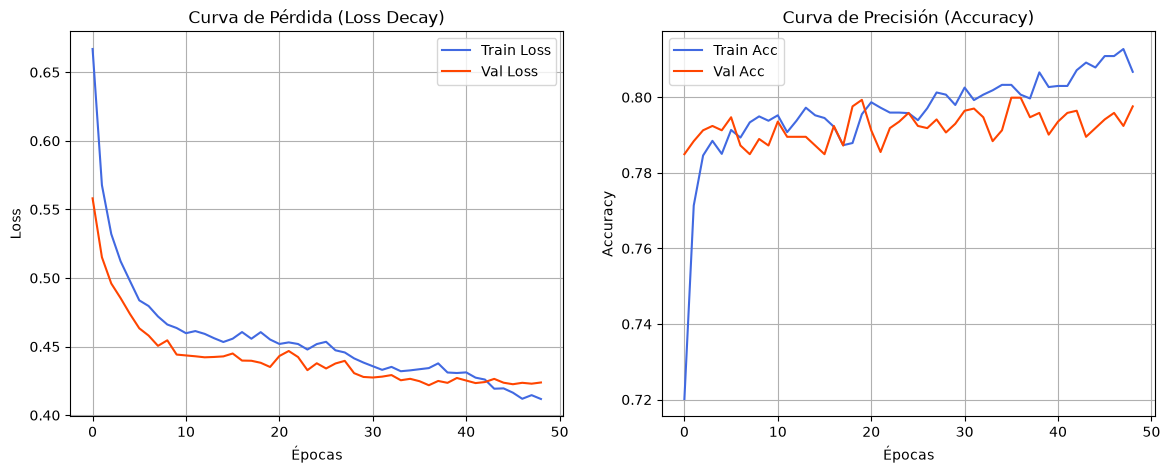

In [5]:
# Curvas de Aprendizaje (Loss y Accuracy) [Exigido en la Guía]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graficar Pérdida (Loss)
ax1.plot(history.history['loss'], label='Train Loss', color='royalblue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orangered')
ax1.set_title('Curva de Pérdida (Loss Decay)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Graficar Precisión (Accuracy)
ax2.plot(history.history['accuracy'], label='Train Acc', color='royalblue')
ax2.plot(history.history['val_accuracy'], label='Val Acc', color='orangered')
ax2.set_title('Curva de Precisión (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.savefig('learning_curves.png')
plt.show()

### 5. EVALUACIÓN Y ANÁLISIS DE ERRORES

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- INFORME DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       861
           1       0.79      0.82      0.81       878

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



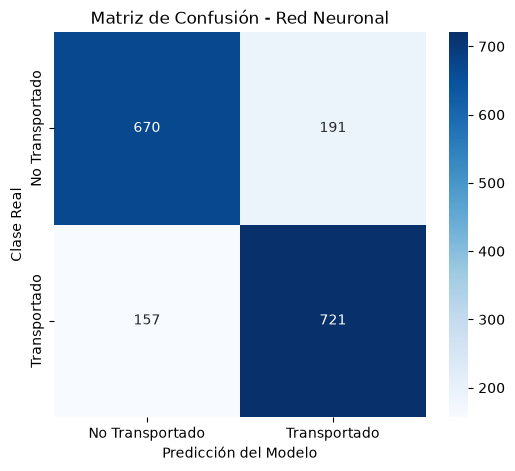


--- ANÁLISIS DE ERRORES ---
Total de errores en validación: 348 de 1739

Distribución de errores según el Planeta de Origen:
HomePlanet
Earth     0.766764
Mars      0.137026
Europa    0.096210
Name: proportion, dtype: float64

Distribución de errores según Criodesaceleración (CryoSleep):
CryoSleep
False    0.659884
True     0.340116
Name: proportion, dtype: float64


In [6]:
val_preds_proba = model.predict(X_val_trans)
val_preds = (val_preds_proba > 0.5).astype(int).flatten()

print("\n--- INFORME DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_val, val_preds))

# Matriz de Confusión
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Transportado', 'Transportado'], yticklabels=['No Transportado', 'Transportado'])
plt.title('Matriz de Confusión - Red Neuronal')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.savefig('confusion_matrix.png')
plt.show()

# Identificar dónde comete fallos el modelo (Análisis de Errores) [Exigido en la Guía]
X_val_analysis = X_val.copy()
X_val_analysis['Real'] = y_val
X_val_analysis['Prediccion'] = val_preds
X_val_analysis['Error'] = X_val_analysis['Real'] != X_val_analysis['Prediccion']

# Extraer los perfiles de error más comunes
errores = X_val_analysis[X_val_analysis['Error'] == True]
print(f"\n--- ANÁLISIS DE ERRORES ---")
print(f"Total de errores en validación: {len(errores)} de {len(X_val)}")
print("\nDistribución de errores según el Planeta de Origen:")
print(errores['HomePlanet'].value_counts(normalize=True))
print("\nDistribución de errores según Criodesaceleración (CryoSleep):")
print(errores['CryoSleep'].value_counts(normalize=True))

### GENERACIÓN DEL ARCHIVO DE SUBMISSION PARA KAGGLE

In [8]:
print("--- GENERANDO PREDICCIONES PARA TEST SET ---")

# 1. Aplicar las mismas transformaciones de ingeniería de variables al conjunto de test
# (Nota: 'test_processed' ya fue creado en tu script con la función preprocess_features)
X_test_final = test_processed[num_features + cat_features]

# 2. Transformar las características usando el pipeline ya ajustado (¡Muy importante usar .transform() y NO .fit_transform()!)
X_test_trans = preprocessor.transform(X_test_final)

# 3. Realizar las predicciones con la Red Neuronal entrenada
# El modelo nos devolverá probabilidades entre 0 y 1 debido a la activación Sigmoid de la última capa
test_preds_proba = model.predict(X_test_trans)

# 4. Convertir las probabilidades a valores Booleanos (True / False) como pide Kaggle
# Si la probabilidad es mayor a 0.5, el pasajero fue transportado (True). Si no, False.
test_preds_boolean = (test_preds_proba > 0.5).astype(bool).flatten()

# 5. Crear el DataFrame de submission con el formato exacto requerido
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_preds_boolean
})

# 6. Guardar el archivo CSV listo para subir
submission_file_path = 'submission_3.csv'
submission_df.to_csv(submission_file_path, index=False)

# 7. Verificación rápida del archivo generado
print(f"\n✅ ¡Archivo '{submission_file_path}' creado con éxito!")
print("\nPrimeras 5 filas del archivo generado:")
print(submission_df.head())

print("\nDistribución de tus predicciones para el conjunto de test:")
print(submission_df['Transported'].value_counts())

--- GENERANDO PREDICCIONES PARA TEST SET ---
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step

✅ ¡Archivo 'submission_3.csv' creado con éxito!

Primeras 5 filas del archivo generado:
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

Distribución de tus predicciones para el conjunto de test:
Transported
True     2203
False    2074
Name: count, dtype: int64
